> **Split workflow:** prefer the dedicated notebooks:
> 1. [`unfolding-gen1-final.ipynb`](unfolding-gen1-final.ipynb) — rebuild Gen1 unfold (χ²=34.5/12) and save ingredients/results
> 2. [`generator_predictions.ipynb`](generator_predictions.ipynb) — load generators → `generator_predictions.pkl`
> 3. [`measurement_plots.ipynb`](measurement_plots.ipynb) — load unfold + generators → final plots
>
> This notebook is kept as the legacy monolithic version.


# Generator Comparison

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

# Notebook-only: for del_alpha, put Data + Norm. Syst. Unc. upper-left;
# remaining (model) entries lower-right in a single column.
_plot_unfolded_result_orig = plot_unfolded_result

def plot_unfolded_result(unfold, measured, models, var_config, *args, **kwargs):
    _orig_legend = plt.legend
    split_legend = var_config.var_save_name == "tki-del_alpha"

    def _legend(handles, labels, **leg_kwargs):
        if not split_legend or len(handles) < 3:
            return _orig_legend(handles, labels, **leg_kwargs)
        # Data + Norm. Syst. Unc.
        leg_data = _orig_legend(
            handles[:2], labels[:2],
            loc="upper left", fontsize=12, frameon=False, ncol=1,
        )
        plt.gca().add_artist(leg_data)
        # models (and any remaining entries)
        return _orig_legend(
            handles[2:], labels[2:],
            loc="lower right", bbox_to_anchor=(1.0, 0.04),
            fontsize=12, frameon=False, ncol=1,
        )

    plt.legend = _legend
    try:
        return _plot_unfolded_result_orig(
            unfold, measured, models, var_config, *args, **kwargs
        )
    finally:
        plt.legend = _orig_legend


In [19]:
save_fig = True
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
today_str = "PRL"
save_fig_dir = path.join(save_fig_base_dir, f"generator_comparison-{today_str}")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/generator_comparison-PRL


# Cross section model comparisons

In [20]:
import awkward as ak

BRANCHES_NU_SIG = ["PDGnu", "cc", "Enu_true", "fScaleFactor", "Weight", "dpt", "dalphat", "dphit"]
BRANCHES_TRK_SIG = ["pdg", "px", "py", "pz", "E"]
BRANCHES_VTX_SIG = ["px_vert", "py_vert", "pz_vert"]


def _genie_trk_to_df(trk_arr):
    counts = ak.num(trk_arr["pdg"])
    n_ev = len(counts)
    event_ids = np.repeat(np.arange(n_ev), counts)
    subentry = ak.flatten(ak.unflatten(np.arange(ak.sum(counts)), counts))
    flat = ak.zip(
        {
            "event": event_ids,
            "subentry": subentry,
            **{c: ak.flatten(trk_arr[c]) for c in BRANCHES_TRK_SIG},
        }
    )
    return ak.to_dataframe(flat).set_index(["event", "subentry"])


def _genie_add_trk_counts(nudf, trkdf):
    """Match makedf mcnu: multiplicity counts use |pdg| and p thresholds; leading μ/p
    are highest-momentum FS particles (mcprim sort genE → last), not first listed track."""
    nudf = nudf.copy()
    trkdf = trkdf.copy()
    trkdf["_p"] = np.sqrt(trkdf.px**2 + trkdf.py**2 + trkdf.pz**2)
    for pid, pname, pth in zip([13, 2212, 211, 111], ["mu", "proton", "pi", "pi0"], [0.22, 0.3, 0.07, 0]):
        ntrks = trkdf[(np.abs(trkdf.pdg) == pid) & (trkdf._p > pth)].pdg.groupby(level=[0]).count()
        nudf[f"n{pname}s"] = ntrks.fillna(0)
        # Leading species: μ uses |pdg|; proton uses pdg==2212 (same as mc.p in makedf)
        species = trkdf[trkdf.pdg == pid] if pname == "proton" else trkdf[np.abs(trkdf.pdg) == pid]
        leading = species.sort_values("_p", ascending=False).groupby(level=[0]).head(1)
        leading_p = leading["_p"]
        leading_p.name = f"{pname}_p"
        nudf = nudf.join(leading_p.reset_index(level=[1])[f"{pname}_p"])

        leading_p_dir_z = leading.pz / leading_p
        leading_p_dir_z.name = f"{pname}_dir_z"
        nudf = nudf.join(leading_p_dir_z.reset_index(level=[1])[f"{pname}_dir_z"])
    return nudf


GENIE_FV_DET = "SBND_nohighyz"


def _genie_vtx_cm(nudf):
    return pd.DataFrame(
        {
            "x": nudf.vtx_x.to_numpy(dtype=float) * 100.0,
            "y": nudf.vtx_y.to_numpy(dtype=float) * 100.0,
            "z": nudf.vtx_z.to_numpy(dtype=float) * 100.0,
        }
    )


def _genie_numu_cc(nudf):
    return (nudf.PDGnu == 14) & (nudf.cc == 1)


def _genie_1mu_220(nudf):
    # mc.nmu_220MeVc == 1 (nmus counts |pdg|==13 with p > 0.22 GeV)
    return _genie_numu_cc(nudf) & (nudf.nmus == 1)


def _genie_mu_p_lt1(nudf):
    return _genie_1mu_220(nudf) & (nudf.mu_p < 1.0)


def _genie_1p_300(nudf):
    # mc.np_300MeVc == 1: exactly one proton above 0.3 GeV; lower-p protons allowed
    return _genie_mu_p_lt1(nudf) & (nudf.nprotons == 1)


def _genie_p_p_lt1(nudf):
    # mc.p.genp < 1 GeV on highest-momentum proton (proton_p from sort-by-p leading)
    return _genie_1p_300(nudf) & (nudf.proton_p < 1.0)


def _genie_no_pions(nudf):
    return (
        _genie_p_p_lt1(nudf)
        & (np.nan_to_num(nudf.npis, nan=0) == 0)
        & (np.nan_to_num(nudf.npi0s, nan=0) == 0)
    )


def _genie_flat_signal_mask(nudf):
    """GENIE flat 1p0π: topology only (no vertex FV)."""
    return _genie_no_pions(nudf)


# --- Production mcnu staged masks (mc_nu_df is vtx-FV pre-filtered in §Load production) ---
def _mc_mu_genp(nudf):
    return np.sqrt(
        nudf.mc.mu.genp.x**2 + nudf.mc.mu.genp.y**2 + nudf.mc.mu.genp.z**2
    )


def _mc_p_genp(nudf):
    return np.sqrt(nudf.mc.p.genp.x**2 + nudf.mc.p.genp.y**2 + nudf.mc.p.genp.z**2)


def _mc_numu_cc(nudf):
    return (nudf.mc.iscc == 1) & (nudf.mc.pdg == 14)


def _mc_1mu_220(nudf):
    return _mc_numu_cc(nudf) & (nudf.mc.nmu_220MeVc == 1)


def _mc_mu_p_lt1(nudf):
    return _mc_1mu_220(nudf) & (_mc_mu_genp(nudf) < 1.0)


def _mc_1p_300(nudf):
    return _mc_mu_p_lt1(nudf) & (nudf.mc.np_300MeVc == 1)


def _mc_p_p_lt1(nudf):
    return _mc_1p_300(nudf) & (_mc_p_genp(nudf) < 1.0)


def _mc_no_pions(nudf):
    return _mc_p_p_lt1(nudf) & (nudf.mc.npi_70MeVc == 0) & (nudf.mc.npi0 == 0)


# def _mc_vtx_fv(nudf):
#     """Re-apply vertex FV (redundant if mc_nu_df was pre-filtered)."""
#     return (
#         _mc_no_pions(nudf)
#         & InFV(nudf.mc.position, det=GENIE_FV_DET)
#         & (np.abs(nudf.mc.position.x) > FLAT_ALIGNED_X_CM)
#     )


# def _mc_per_tpc_ends(nudf):
#     return _mc_vtx_fv(nudf) & IsTruthCC1p0piPerTPCFV(nudf)


# def _mc_signal(nudf):
#     return _mc_vtx_fv(nudf)
#     # return IsNuInFV_NumuCC_1p0pi(nudf, signal_truth_fv=SIGNAL_TRUTH_FV)


In [21]:
def get_flatcaf_signals(genie_filename, var_name_list, bins_list):

    XSEC_ADD_FACTOR = 0.97

    n_list = {}
    for var_name, bins in zip(var_name_list, bins_list):

        events_sig = uproot.open(genie_filename + ":FlatTree_VARS")
        genie_nu_df = events_sig.arrays(BRANCHES_NU_SIG, library="pd")
        genie_vert = events_sig.arrays(BRANCHES_VTX_SIG, library="ak")
        genie_trk_df = _genie_trk_to_df(events_sig.arrays(BRANCHES_TRK_SIG, library="ak"))
        genie_nu_df = _genie_add_trk_counts(genie_nu_df, genie_trk_df)
        genie_nu_df["vtx_x"] = ak.fill_none(ak.firsts(genie_vert["px_vert"]), np.nan)
        genie_nu_df["vtx_y"] = ak.fill_none(ak.firsts(genie_vert["py_vert"]), np.nan)
        genie_nu_df["vtx_z"] = ak.fill_none(ak.firsts(genie_vert["pz_vert"]), np.nan)

        genie_sig = _genie_flat_signal_mask(genie_nu_df)
        genie_enu_sig = genie_nu_df.loc[genie_sig, var_name].to_numpy(dtype=float)
        if var_name == "dpt":
            genie_enu_sig = genie_enu_sig / 1e3

        if var_name == "dalphat":
            genie_enu_sig = np.rad2deg(genie_enu_sig)
        elif var_name == "dphit":
            genie_enu_sig = np.rad2deg(genie_enu_sig)

        genie_w_sig = (40.0 * genie_nu_df.loc[genie_sig, "fScaleFactor"] * genie_nu_df.loc[genie_sig, "Weight"]).to_numpy(dtype=float)

        # fig, ax = plt.subplots()

        centers = 0.5 * (bins[:-1] + bins[1:])
        bin_widths = np.diff(bins)

        # wgt_prod = np.ones_like(prod_enu_sig) * XSEC_UNIT * VERSION_CORRECTION
        # n, bins = np.histogram(prod_enu_sig, bins, weights=wgt_prod)
        # ax.hist(centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, label="Production signal")

        wgt_genie = genie_w_sig
        n, bins = np.histogram(genie_enu_sig, bins, weights=genie_w_sig)
        # print(n)
        # ax.hist(centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, ls="--", label="GENIE signal")
        # ax.set_xlabel(r"$E_\nu$ [GeV]")
        # ax.set_ylabel("Density")
        # ax.set_title(r"$\nu_\mu$ CC 1p0$\pi$ signal — truth $E_\nu$ shape")
        # ax.legend()
        # fig.tight_layout()
        # plt.show()

        n_list[var_name] = n * XSEC_ADD_FACTOR

    return n_list

In [22]:
# chi2_list = {
# "muon-p": 9.69,
# "muon-dir_z": 27.35,
# "proton-p": 18.08,
# "proton-dir_z": 13.67,
# "tki-del_Tp": 38.8,
# "tki-del_Tp_x": 28.7,
# "tki-del_Tp_y": 26.6,
# "tki-del_p": 33.6,
# "tki-del_alpha": 3.4,
# "tki-del_phi": 9.5,
# }

In [23]:
# filename = "/pnfs/sbnd/persistent/users/apapadop/neut/bnb.sbnd.neut_6_1_4_numu_cc_gen1_flux.flat.root/neut.flat.root"
# events_sig = uproot.open(filename + ":FlatTree_VARS")
# genie_nu_df = events_sig.arrays(BRANCHES_NU_SIG, library="pd")
# genie_vert = events_sig.arrays(BRANCHES_VTX_SIG, library="ak")
# genie_trk_df = _genie_trk_to_df(events_sig.arrays(BRANCHES_TRK_SIG, library="ak"))
# genie_nu_df = _genie_add_trk_counts(genie_nu_df, genie_trk_df)
# genie_sig = _genie_flat_signal_mask(genie_nu_df)

In [24]:
var_names = ["dpt", "dalphat", "dphit", "mu_p", "proton_p", "mu_dir_z", "proton_dir_z"]
bins = [VariableConfig.tki_del_Tp().bins, 
        VariableConfig.tki_del_alpha().bins, 
        VariableConfig.tki_del_phi().bins,
        VariableConfig.muon_momentum().bins,
        VariableConfig.proton_momentum().bins,
        VariableConfig.muon_direction().bins,
        VariableConfig.proton_direction().bins]

In [10]:
filename = "/pnfs/sbnd/persistent/users/munjung/SBN_CCQE/NuWro/NuWro.flat.root"
nuwro_cache = get_flatcaf_signals(filename, var_names, bins)

In [25]:
filename = "/pnfs/sbnd/persistent/users/apapadop/nuwro/bnb.sbnd.nuwro_25_11_1_gen1_flux_default.flat.root"
nuwro_cache_afro = get_flatcaf_signals(filename, var_names, bins)

filename = "/pnfs/sbnd/persistent/users/apapadop/nuwro/bnb.sbnd.nuwro_25_11_1_gen1_flux_modified.flat.root"
nuwro_cache_newconf = get_flatcaf_signals(filename, var_names, bins)

In [29]:
filename = "/pnfs/sbnd/persistent/users/apapadop/nuwro/bnb.sbnd.nuwro_25_11_1_gen1_flux_default.flat.root"
events_sig = uproot.open(filename + ":FlatTree_VARS")
genie_nu_df = events_sig.arrays(BRANCHES_NU_SIG, library="pd")
genie_nu_df

,PDGnu,cc,Enu_true,fScaleFactor,Weight,dpt,dalphat,dphit
0,14,1,0.924003,3.775557e-45,1.0,514.014465,2.759578,2.473236
1,14,1,0.484734,3.775557e-45,1.0,173.256653,2.485426,1.489560
2,14,1,0.406759,3.775557e-45,1.0,98.887451,3.129214,0.011700
3,14,1,0.857823,3.775557e-45,1.0,95.167122,0.579590,0.120426
4,14,1,1.774766,3.775557e-45,1.0,276.724548,2.157167,0.840116
...,...,...,...,...,...,...,...,...
999995,14,1,0.342798,3.775557e-45,1.0,14.451653,3.030488,0.007200
999996,14,1,0.506836,3.775557e-45,1.0,173.816879,2.326692,0.450777
999997,14,1,0.806128,3.775557e-45,1.0,661.920166,2.911441,2.838862
999998,14,1,0.527314,3.775557e-45,1.0,165.088379,1.499079,0.695832


In [11]:
filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_2_AR23_20i_00_000_SBND_gen1.flat.root"
baseline_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/pnfs/sbnd/persistent/users/apapadop/neut/bnb.sbnd.neut_6_1_4_numu_cc_gen1_flux.flat.root/neut.flat.root"
neut_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/pnfs/sbnd/persistent/users/apapadop/GiBUU_Samples/GiBUU2025_patch5/gibuu2025_patch5_cc_numu_gen1_flux.root"
gibuu_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_0_SBN25_00a_00_000_SBND.flat.root"
sf_cache = get_flatcaf_signals(filename, var_names, bins)

In [12]:
filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_2_AR25_20i_01_000_SBND_gen1.flat.root"
AR25_20i_01_000_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_2_AR25_20i_01_001_SBND_gen1.flat.root"
AR25_20i_01_001_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_2_AR25_20i_02_000_SBND_gen1.flat.root"
AR25_20i_02_000_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_2_AR25_22i_00_000_SBND_gen1.flat.root"
AR25_22i_00_000_cache = get_flatcaf_signals(filename, var_names, bins)

In [13]:
filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_0-CRPA_G21_11a_00_000_SBND.flat.root"
CRPA_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs_old/14_1000180400_CC_v3_6_0-HF_G21_11a_00_000_SBND.flat.root"
HF_cache = get_flatcaf_signals(filename, var_names, bins)

# Compare just generators

In [14]:
var_config = VariableConfig.tki_del_Tp()
bins = var_config.bins
print("Bins for dpt: ", bins)

var_config = VariableConfig.tki_del_alpha()
bins = var_config.bins
print("Bins for dalphat: ", bins)

Bins for dpt:  [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.45 0.55 0.65 0.8  1.  ]
Bins for dalphat:  [  0  25  50  75 100 120 140 160 180]


[1.05172894e-37 2.49112931e-37 2.91726137e-37 2.27439404e-37
 1.20430420e-37 5.71221497e-38 3.53631552e-38 2.52838160e-38
 1.61033653e-38 8.63080257e-39 3.51401523e-39 6.98480522e-40]


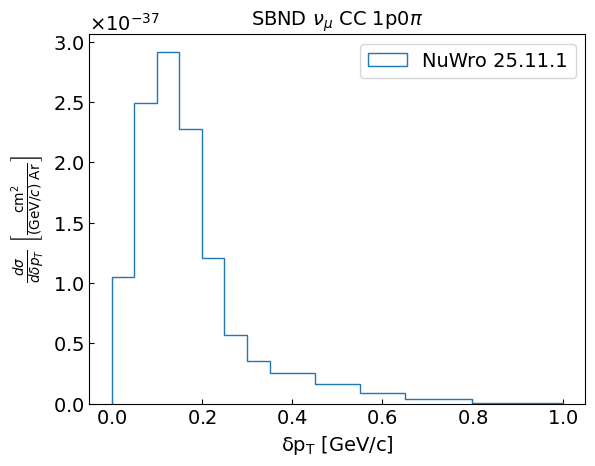

[2.62516684e-40 2.74535264e-40 2.95466102e-40 3.28839914e-40
 3.67461172e-40 3.92806878e-40 3.98605446e-40 3.89343948e-40]


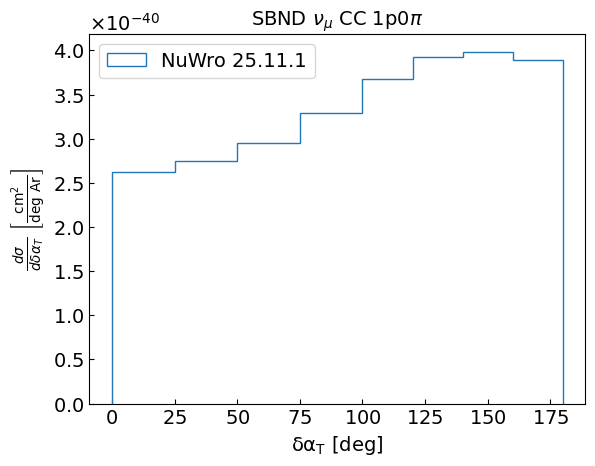

In [15]:
import numpy as np

# For tki_del_Tp
var_config = VariableConfig.tki_del_Tp()
bins = var_config.bins

bin_diff = np.diff(bins)
n, bins, _ = plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["dpt"] / bin_diff, histtype="step", label="NuWro 25.11.1")
print(n)

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show()

# Save histogram values and binning to a text file
output_tp = {
    "variable": "dpt",
    "bin_edges": bins.tolist(),
    "bin_counts": n.tolist()
}
with open("nuwro_tki_del_Tp_hist.txt", "w") as f:
    f.write(f"Variable: {output_tp['variable']}\n")
    f.write(f"Bin edges: {output_tp['bin_edges']}\n")
    f.write(f"Bin counts: {output_tp['bin_counts']}\n")


# For tki_del_alpha
var_config = VariableConfig.tki_del_alpha()
bins = var_config.bins

bin_diff = np.diff(bins)
n, bins, _ = plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["dalphat"] / bin_diff, histtype="step", label="NuWro 25.11.1")
print(n)

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show()

# Save histogram values and binning to a text file
output_alpha = {
    "variable": "dalphat",
    "bin_edges": bins.tolist(),
    "bin_counts": n.tolist()
}
with open("nuwro_tki_del_alpha_hist.txt", "w") as f:
    f.write(f"Variable: {output_alpha['variable']}\n")
    f.write(f"Bin edges: {output_alpha['bin_edges']}\n")
    f.write(f"Bin counts: {output_alpha['bin_counts']}\n")

In [27]:
nuwro_cache_afro

{'dpt': array([5.21510078e-39, 1.23838135e-38, 1.44420204e-38, 1.13022660e-38,
        6.00073520e-39, 2.79886841e-39, 1.75584826e-39, 2.53708793e-39,
        1.57331973e-39, 8.32658225e-40, 5.36745204e-40, 1.41803864e-40]),
 'dalphat': array([6.48928467e-39, 6.73275370e-39, 7.37043161e-39, 8.18140908e-39,
        7.28136472e-39, 7.84345297e-39, 7.91874965e-39, 7.71585879e-39]),
 'dphit': array([2.08933637e-38, 1.54766905e-38, 9.00000411e-39, 4.55076139e-39,
        3.26603011e-39, 1.73123767e-39, 1.44631152e-39, 9.76073497e-40,
        7.42565894e-40, 6.12774341e-40, 8.37492448e-40]),
 'mu_p': array([7.33029292e-39, 7.81825642e-39, 7.40500363e-39, 6.62522887e-39,
        5.80590138e-39, 5.01792309e-39, 4.20416228e-39, 3.47258326e-39,
        4.32384591e-39, 3.71575930e-39, 2.34166814e-39, 1.47268000e-39]),
 'proton_p': array([8.37258061e-39, 8.58953466e-39, 7.30377794e-39, 5.88266298e-39,
        5.39675035e-39, 4.89970437e-39, 4.30509499e-39, 3.72191195e-39,
        3.16407196e-39, 2

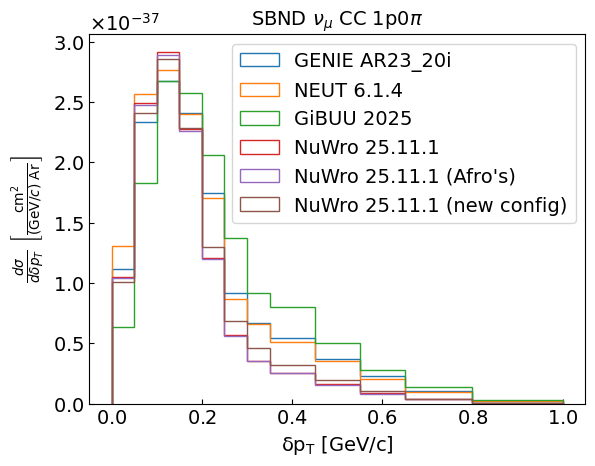

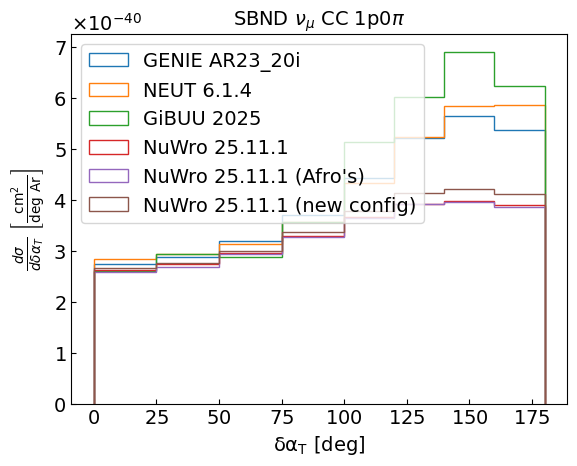

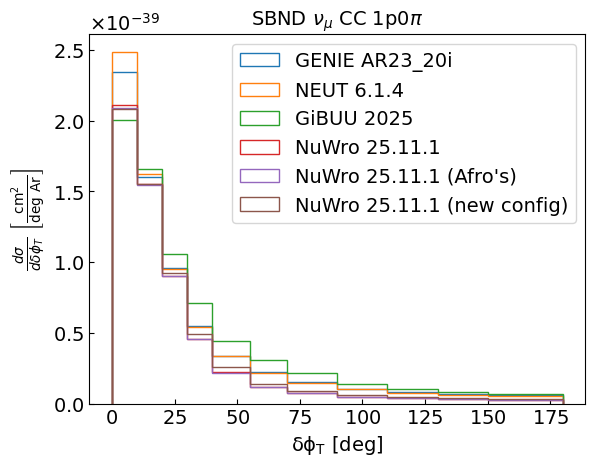

In [26]:
var_config = VariableConfig.tki_del_Tp()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["dpt"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["dpt"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["dpt"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["dpt"] / bin_diff, histtype="step", label="NuWro 25.11.1")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache_afro["dpt"] / bin_diff, histtype="step", label="NuWro 25.11.1 (Afro's)")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache_newconf["dpt"] / bin_diff, histtype="step", label="NuWro 25.11.1 (new config)")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();

var_config = VariableConfig.tki_del_alpha()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["dalphat"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["dalphat"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["dalphat"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["dalphat"] / bin_diff, histtype="step", label="NuWro 25.11.1")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache_afro["dalphat"] / bin_diff, histtype="step", label="NuWro 25.11.1 (Afro's)")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache_newconf["dalphat"] / bin_diff, histtype="step", label="NuWro 25.11.1 (new config)")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();


var_config = VariableConfig.tki_del_phi()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["dphit"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["dphit"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["dphit"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["dphit"] / bin_diff, histtype="step", label="NuWro 25.11.1")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache_afro["dphit"] / bin_diff, histtype="step", label="NuWro 25.11.1 (Afro's)")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache_newconf["dphit"] / bin_diff, histtype="step", label="NuWro 25.11.1 (new config)")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();


In [ ]:
baseline_cache

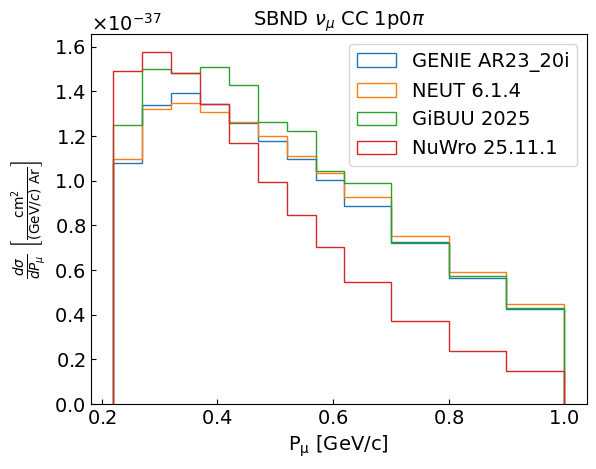

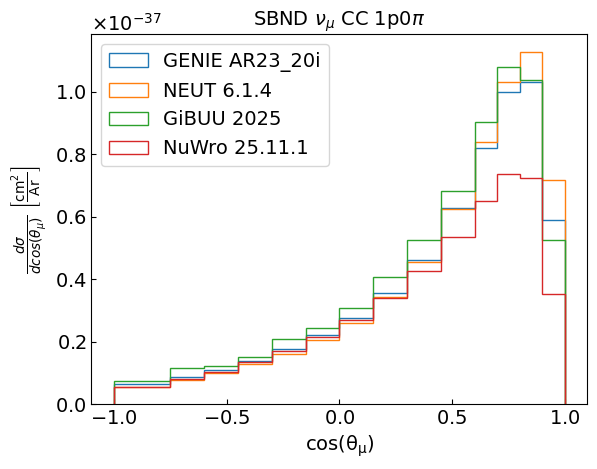

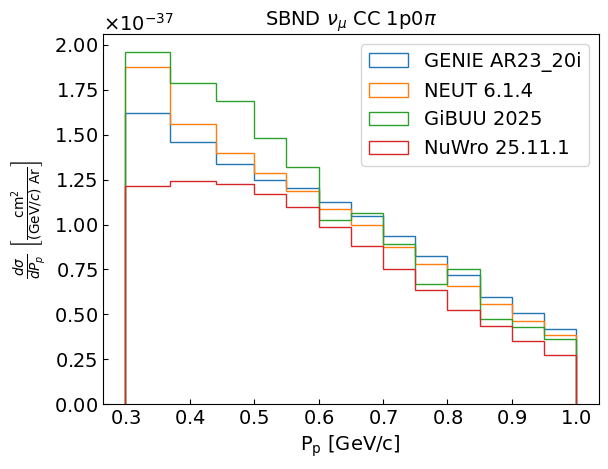

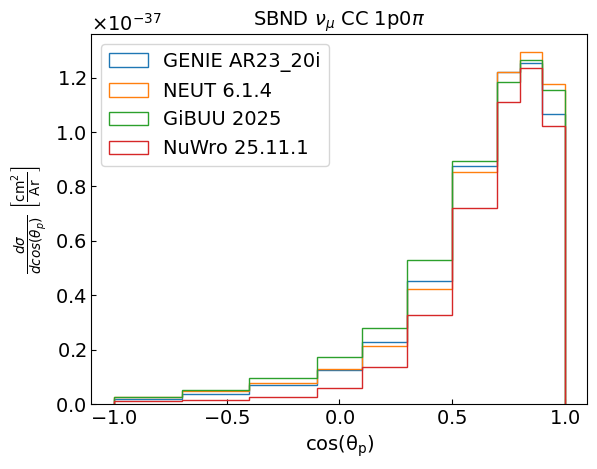

In [30]:
var_config = VariableConfig.muon_momentum()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["mu_p"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["mu_p"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["mu_p"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["mu_p"] / bin_diff, histtype="step", label="NuWro 25.11.1")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();

var_config = VariableConfig.muon_direction()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["mu_dir_z"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["mu_dir_z"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["mu_dir_z"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["mu_dir_z"] / bin_diff, histtype="step", label="NuWro 25.11.1")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();


var_config = VariableConfig.proton_momentum()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["proton_p"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["proton_p"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["proton_p"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["proton_p"] / bin_diff, histtype="step", label="NuWro 25.11.1")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();

var_config = VariableConfig.proton_direction()
bins = var_config.bins

bin_diff = np.diff(bins)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=baseline_cache["proton_dir_z"] / bin_diff, histtype="step", label="GENIE AR23_20i")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=neut_cache["proton_dir_z"] / bin_diff, histtype="step", label="NEUT 6.1.4")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=gibuu_cache["proton_dir_z"] / bin_diff / 1000, histtype="step", label="GiBUU 2025")
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=nuwro_cache["proton_dir_z"] / bin_diff, histtype="step", label="NuWro 25.11.1")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend()
plt.title(r"SBND $\nu_\mu$ CC 1p0$\pi$")
plt.show();



# Compare to Measurement

In [31]:
# load unfold_cache from pickle file
outdir = "/exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS"
with open(os.path.join(outdir, "Gen1_unfold_cache_efielddet_noneutron.pkl"), "rb") as f:
    unfold_cache = pickle.load(f)

# Plot

In [32]:
save_fig_dir

var_config = VariableConfig.tki_del_Tp()

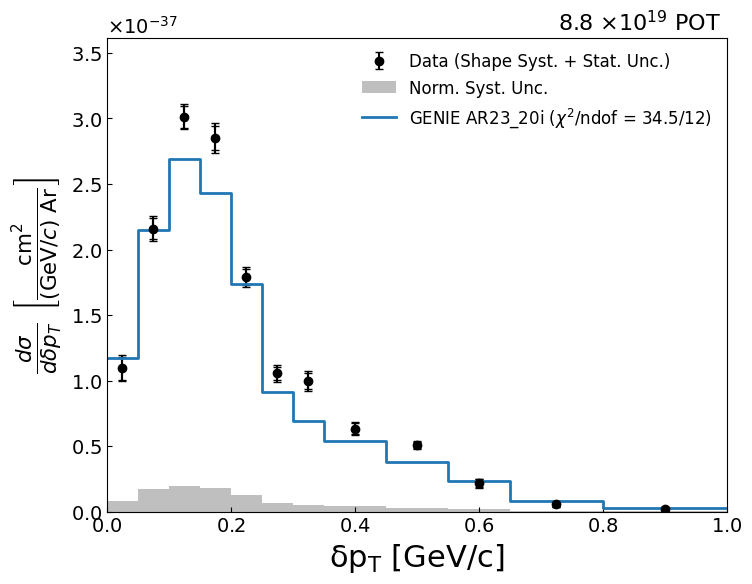

In [33]:
for var_config in [
    # VariableConfig.all_events(),
    # VariableConfig.muon_momentum(),
    # VariableConfig.muon_direction(),
    # VariableConfig.proton_momentum(),
    # VariableConfig.proton_direction(),
    VariableConfig.tki_del_Tp(),
    # VariableConfig.tki_del_Tp_x(),
    # VariableConfig.tki_del_Tp_y(),
    # VariableConfig.tki_del_p(),
    # VariableConfig.tki_del_alpha(),
    # VariableConfig.tki_del_phi()
    ]:
    models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"]}
              # "SF": sf_cache[genie_var_name] ,
            #   "NuWro 26": [nuwro_cache[genie_var_name], "C3"] } #,  "AR23": nevts_dict["GENIE AR23"]}
    
    xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
    measured = unfold_cache[var_config.var_save_name]["measured"]
    unfold = unfold_cache[var_config.var_save_name]["unfold"]
    
    save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec"
    plot_unfolded_result(unfold, 
                        measured, 
                        models,
                        var_config,
                        xsec_unit=1/np.unique(xsec_unit)[0],
                        save_fig=save_fig, 
                        save_name=save_name,
                        textloc=[0.5, 0.9],
                        approval="",
                        data=True,
                        closure_test=False)

In [34]:
# variable to plot
var_config = VariableConfig.tki_del_Tp()
genie_var_name = "dpt"
bins = var_config.bins

# var_config = VariableConfig.tki_del_alpha()
# genie_var_name = "dalphat"
# bins = var_config.bins

# var_config = VariableConfig.tki_del_phi()
# genie_var_name = "dphit"
# bins = var_config.bins

# var_config = VariableConfig.muon_momentum()
# genie_var_name = "mu_p"
# bins = var_config.bins

# var_config = VariableConfig.proton_momentum()
# genie_var_name = "proton_p"
# bins = var_config.bins

# var_config = VariableConfig.muon_direction()
# genie_var_name = "mu_dir_z"
# bins = var_config.bins

# var_config = VariableConfig.proton_direction()
# genie_var_name = "proton_dir_z"
# bins = var_config.bins

In [35]:
# plt.rcParams['figure.dpi'] = 300

In [36]:
save_fig = True
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/generator_comparison-PRL'

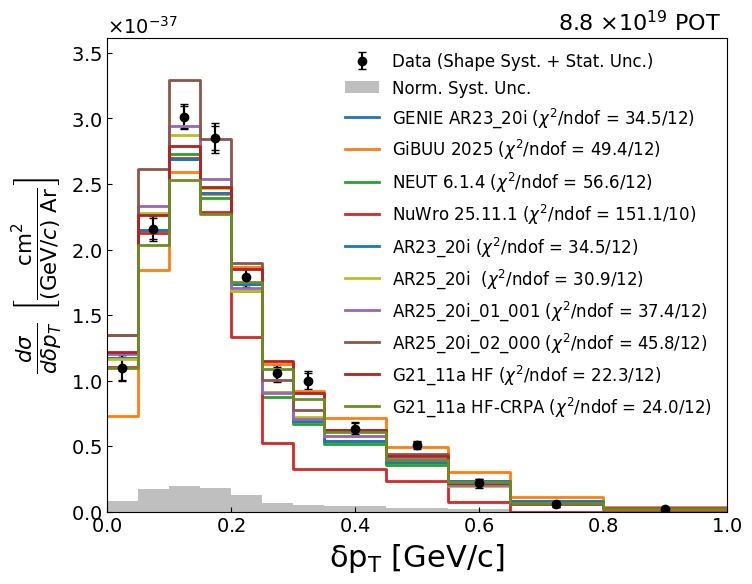

In [37]:
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GiBUU 2025": [gibuu_cache[genie_var_name] / 1000, "C1"],
          "NEUT 6.1.4": [neut_cache[genie_var_name] , "C2"],
          # "SF": sf_cache[genie_var_name] ,
          "NuWro 25.11.1": [nuwro_cache[genie_var_name], "C3"],
          "AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "AR25_20i ": [AR25_20i_01_000_cache[genie_var_name], "C8"],
          "AR25_20i_01_001": [AR25_20i_01_001_cache[genie_var_name], "C4"],
          "AR25_20i_02_000": [AR25_20i_02_000_cache[genie_var_name], "C5"],
          "AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "G21_11a HF": [HF_cache[genie_var_name], "firebrick"],
          "G21_11a HF-CRPA": [CRPA_cache[genie_var_name], "olivedrab"]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-generators"
plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="å",
                    data=True,
                    closure_test=False)

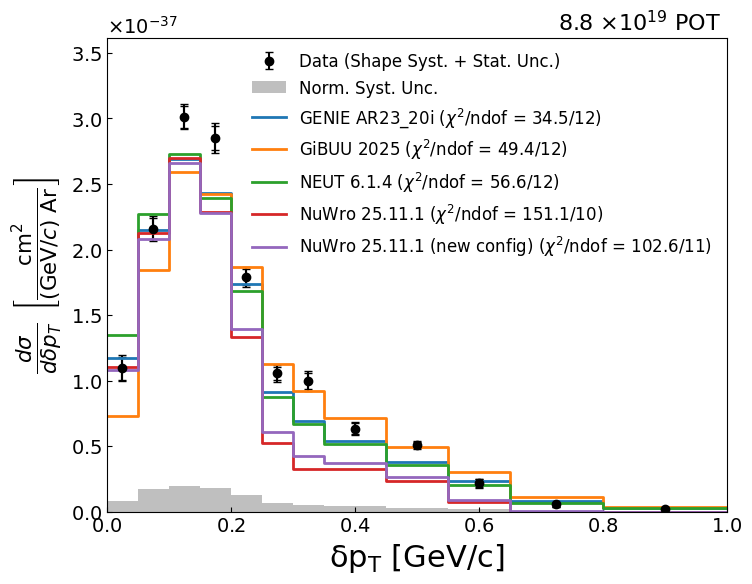

In [40]:
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GiBUU 2025": [gibuu_cache[genie_var_name] / 1000, "C1"],
          "NEUT 6.1.4": [neut_cache[genie_var_name] , "C2"],
          # "SF": sf_cache[genie_var_name] ,
          "NuWro 25.11.1": [nuwro_cache[genie_var_name], "C3"],
          "NuWro 25.11.1 (new config)": [nuwro_cache_newconf[genie_var_name], "C4"]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-generators"
plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="å",
                    data=True,
                    closure_test=False)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 12 is different from 11)

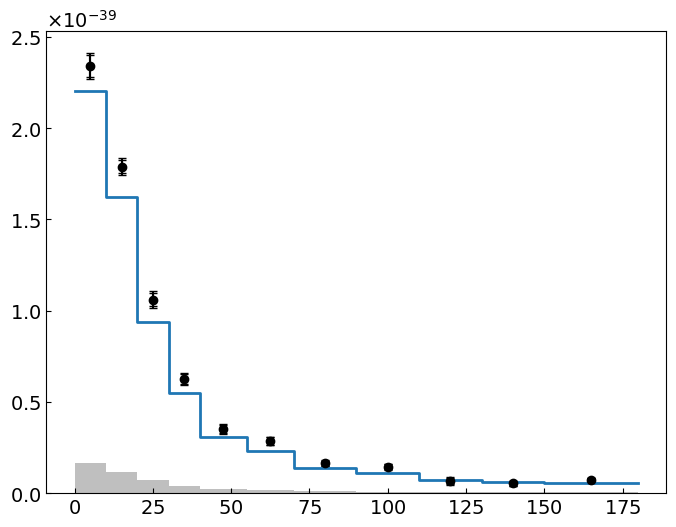

In [21]:
save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-AR25"
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GENIE AR25_20i ": [AR25_20i_01_000_cache[genie_var_name], "C8"],
          "GENIE AR25_20i MINERvA $F_A$": [AR25_20i_01_001_cache[genie_var_name], "C4"],
          "GENIE AR25_20i LQCD $F_A$": [AR25_20i_02_000_cache[genie_var_name], "C5"]}
        #   "AR25_22i_00_000": AR25_22i_00_000_cache[genie_var_name]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="",
                    data=True,
                    closure_test=False)

In [ ]:
save_name

In [ ]:
save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison"
models = {"AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "AR25_20i ": [AR25_20i_01_000_cache[genie_var_name], "C8"],
          "AR25_20i_01_001": [AR25_20i_01_001_cache[genie_var_name], "C4"],
          "AR25_20i_02_000": [AR25_20i_02_000_cache[genie_var_name], "C5"],
          "AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "G21_11a HF": [HF_cache[genie_var_name], "firebrick"],
          "G21_11a HF-CRPA": [CRPA_cache[genie_var_name], "olivedrab"]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="",
                    data=True,
                    closure_test=False)

In [ ]:

save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-HF"
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GENIE G21_11a HF": [HF_cache[genie_var_name], "firebrick"],
          "GENIE G21_11a HF-CRPA": [CRPA_cache[genie_var_name], "olivedrab"]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="",
                    data=True,
                    closure_test=False)

In [ ]:
save_fig_dir

In [ ]:
plot_unfolded_result

In [ ]:
xsec_unit

In [ ]:
1/np.unique(xsec_unit)[0]